In [30]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO

plots_filepath = 'plots/july-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

In [31]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_fdv_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    if breakout_asset is None:
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
            for slug in assets
        ]  
        
    else:
        exclude = breakout_asset[0]
        
            # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
            if slug != exclude
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
            for slug in assets
            if slug != exclude
        ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select {category_title} annualized {bottom_metric} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    if breakout_asset is None:
        # Calculate statistical percentiles for multiple
        median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
        latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
        mean_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].mean(), 0)
        percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
        percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
        stdev_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].std(),0)
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics:")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_cohort:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
        print(f'Standard Deviation: {stdev_cohort:,.0f}x')
        print()
    
        return stats_cohort

    else:
        # Calculate statistical percentiles for multiple
        median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
        latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
        mean_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].mean(), 0)
        percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
        percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
        stdev_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].std(),0)
        
        median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
        latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)
        mean_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].mean(), 0)
        percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
        percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
        stdev_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].std(),0)
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        stats_breakout = {
            "median_multiple": median_breakout,
            'latest_multiple': latest_breakout_multiple,
            'mean_multiple': mean_breakout,
            "80th_percentile_multiple": percentile_80_breakout,
            "20th_percentile_multiple": percentile_20_breakout,
            'stdev_multiple': stdev_breakout
        }
        
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_cohort:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
        print(f'Standard Deviation: {stdev_cohort:,.0f}x')
        print()
        
        print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
        print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_breakout:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
        print(f'Standard Deviation: {stdev_breakout:,.0f}x')
        print()
    
        return stats_cohort, stats_breakout

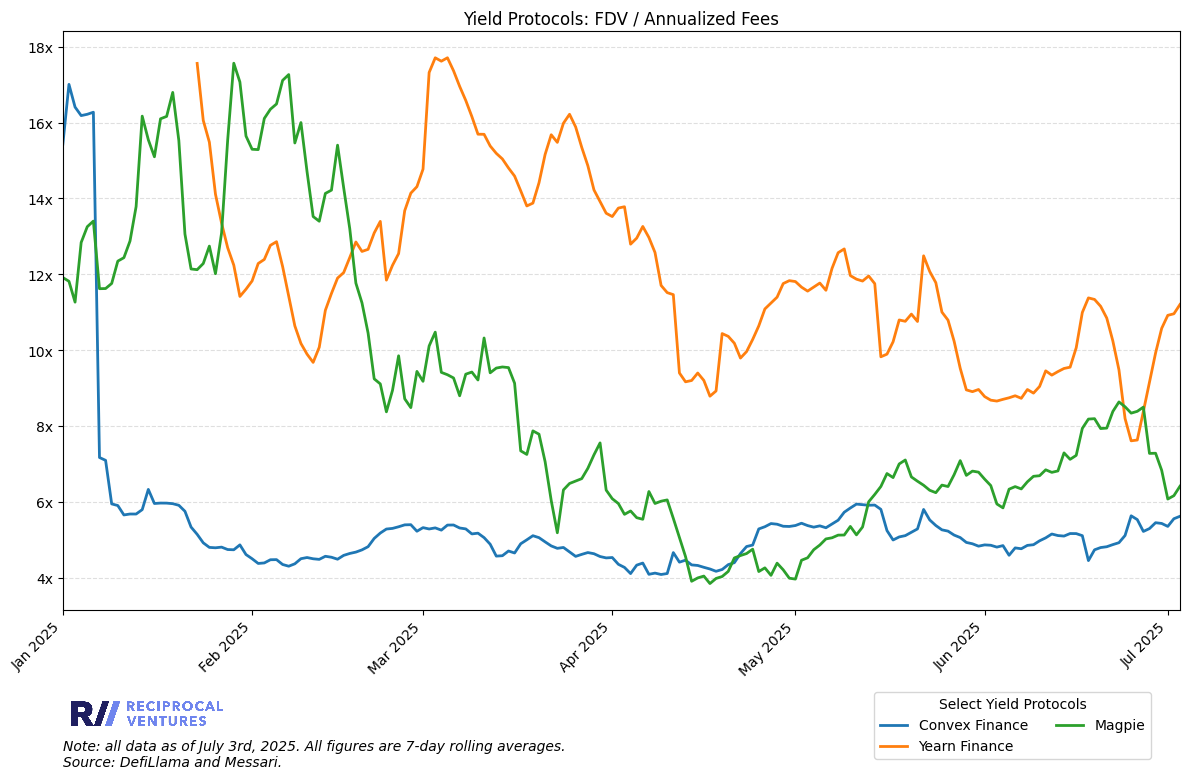


Yield Protocols FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 8x
Latest Multiple: 8x
Mean FDV / Annualized Fees: 8x
80th Percentile FDV / Annualized Fees: 10x
20th Percentile FDV / Annualized Fees: 7x
Standard Deviation: 2x



In [32]:
# Call the function for perp dexs
yield_protocols = {
    'convex-finance': 'Convex Finance',
    'yearn-finance': 'Yearn Finance',
    'magpie-ecosystem': 'Magpie',
}


# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = yield_protocols
breakout_asset = None
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Yield Protocols'

fee_yield_stats = revenue_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [33]:
# Function for plotting tvl / mcap or fdv charts for a set of assets

def tvl_vs_fdv_asset(start_date, assets, breakout_asset, top_metric, category_title):
    df_master = None
    # Loadtvl and FDV data
    for asset_slug, asset_name in assets.items():
        tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
        with open(tvl_path) as tvl_f:
            tvl_data = json.load(tvl_f)

        tvl_df = pd.DataFrame(
            tvl_data['tvl'],
            columns=['date', 'totalLiquidityUSD']
        )
        tvl_df.rename(columns={
            'date': 'timestamp',
            'totalLiquidityUSD': f'{asset_slug}-TVL'
        }, inplace=True)
        tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
        tvl_df = tvl_df[['date', f'{asset_slug}-TVL']]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(tvl_df, fdv_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-TVL']
        interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    if breakout_asset is None:
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-TVL-multiple"
            for slug in assets
        ]    
        
    else:
        exclude = breakout_asset[0]
        
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
            if slug != exclude
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-TVL-multiple"
            for slug in assets
            if slug != exclude
        ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-TVL-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / TVL')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.1f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select {category_title} TVL multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    if breakout_asset is None:
        # Calculate statistical percentiles for multiple
        median_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].median()
        latest_cohort_multiple = df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1]
        mean_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].mean()
        percentile_80_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80)
        percentile_20_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20)
        stdev_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].std()
        
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
        
        # Print results in human-readable format
        print(f"{category_title} {top_metric} / TVL Statistics:")
        print(f"Median {top_metric} / TVL: {median_cohort:,.1f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_cohort:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_cohort:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_cohort:,.1f}x")
        print(f'Standard Deviation: {stdev_cohort:,.1f}x')
        print()
    
        return stats_cohort
    
    else:
        # Calculate statistical percentiles for multiple
        median_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].median()
        latest_cohort_multiple = df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1]
        mean_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].mean()
        percentile_80_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80)
        percentile_20_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20)
        stdev_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].std()
        
        median_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].median()
        latest_breakout_multiple = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].dropna().iloc[-1]
        mean_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].mean()
        percentile_80_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].quantile(0.80)
        percentile_20_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].quantile(0.20)
        stdev_breakout = df_master[f'{top_metric}_weighted_avg_multiple'].std()
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        stats_breakout = {
            "median_multiple": median_breakout,
            'latest_multiple': latest_breakout_multiple,
            'mean_multiple': mean_breakout,
            "80th_percentile_multiple": percentile_80_breakout,
            "20th_percentile_multiple": percentile_20_breakout,
            'stdev_multiple': stdev_cohort
        }
        
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / TVL Statistics (Excluding {breakout_asset[1]}):")
        print(f"Median {top_metric} / TVL: {median_cohort:,.1f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_cohort:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_cohort:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_cohort:,.1f}x")
        print(f'Standard Deviation: {stdev_cohort:,.1f}x')
        print()
        
        print(f"{breakout_asset[1]} {top_metric} / TVL Statistics:")
        print(f"Median {top_metric} / TVL: {median_breakout:,.1f}x")
        print(f"Latest Multiple: {latest_breakout_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_breakout:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_breakout:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_breakout:,.1f}x")
        print(f'Standard Deviation: {stdev_breakout:,.1f}x')
        print()
    
        return stats_cohort, stats_breakout, df_master

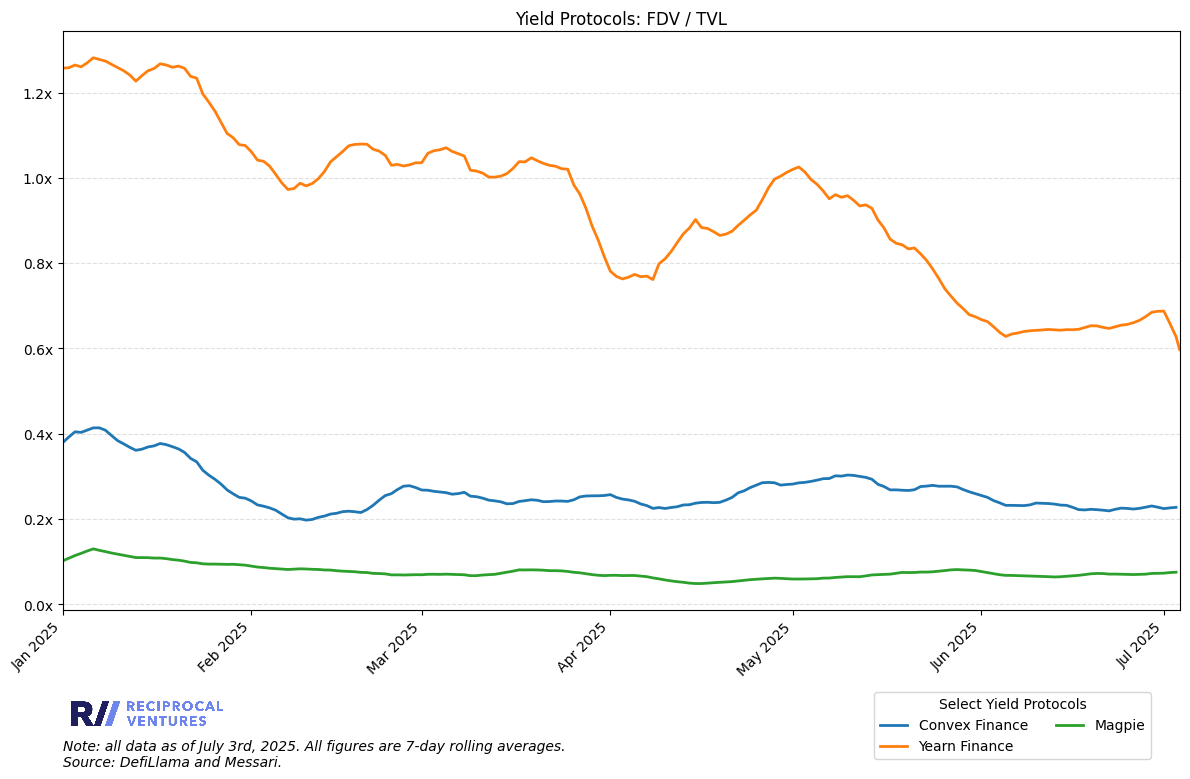

Yield Protocols FDV / TVL Statistics:
Median FDV / TVL: 0.5x
Latest Multiple: 0.3x
Mean FDV / TVL: 0.5x
80th Percentile FDV / TVL: 0.6x
20th Percentile FDV / TVL: 0.4x
Standard Deviation: 0.1x



In [34]:
# Call the function

assets = yield_protocols
breakout_asset = None
top_metric = 'FDV'
category_title = 'Yield Protocols'

tvl_yield_stats= tvl_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    top_metric     = top_metric,
    category_title = category_title
)

In [35]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    f'FDV / Annualized {bottom_metric}':              fee_yield_stats,
    'TVL / FDV':                tvl_yield_stats

})

combined_stats.index = [
    'Median',
    'Most Recent',
    'Mean',
    '80th Percentile',
    '20th Percentile',
    'Standard Deviation'
]

# Re-order and keep only the fields I want to display
desired_order = ['Mean', 'Standard Deviation', 'Most Recent']
filtered_stats = combined_stats.reindex(desired_order)

# Build the Styler with my centered title
title_html = f"<strong>Select {category_title}: TTM Multiples</strong>"

styled = (
    filtered_stats
      .style
      .set_caption(title_html)
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("caption-side", "top"),
             ("text-align", "center"),
             ("font-weight", "bold"),
             ("text-decoration", "underline")
           ]},
          # turn off bold for *all* index & header cells
          {"selector": ".blank, .row_heading, .col_heading",
           "props": [
             ("font-weight", "normal")
           ]},
      ], overwrite=False)
      .format(lambda v: f"{v:,.1f}x" if pd.notnull(v) else "")
)

# Render the table to an HTML string
table_html = styled.to_html()   # or .render() on older pandas

# Build my notes block
notes_html = f"""
<div style="text-align:left; margin-top:1em; font-size:0.9em">
  Notes:<br>
  • All data from {start_date} to {date}.<br>
  • Includes: Convex, Yearn, and Magpie.<br>
  • Multiples are FDV-weighted.<br>
  Sources: DefiLlama and Messari.
</div>
"""

# Combine and display as one HTML
full_html = table_html + notes_html
display(HTML(full_html))

,FDV / Annualized Fees,TVL / FDV
Mean,8.0x,0.5x
Standard Deviation,2.0x,0.1x
Most Recent,8.0x,0.3x
